# Mumbai Real Estate Price Prediction: Regression Analysis
### Dataset: Mumbai 2026 Real Estate Estimates

## 1. Import Libraries and Data
We begin by importing the necessary libraries for data manipulation, visualization, and machine learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Algorithms
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Load dataset (Assumes the CSV generated in previous steps)
df = pd.read_csv('dataset.csv')

## 2. Exploratory Data Analysis (EDA)

We will address 10 key questions to understand the market dynamics.

### Q1: What is the distribution of property prices in Mumbai?

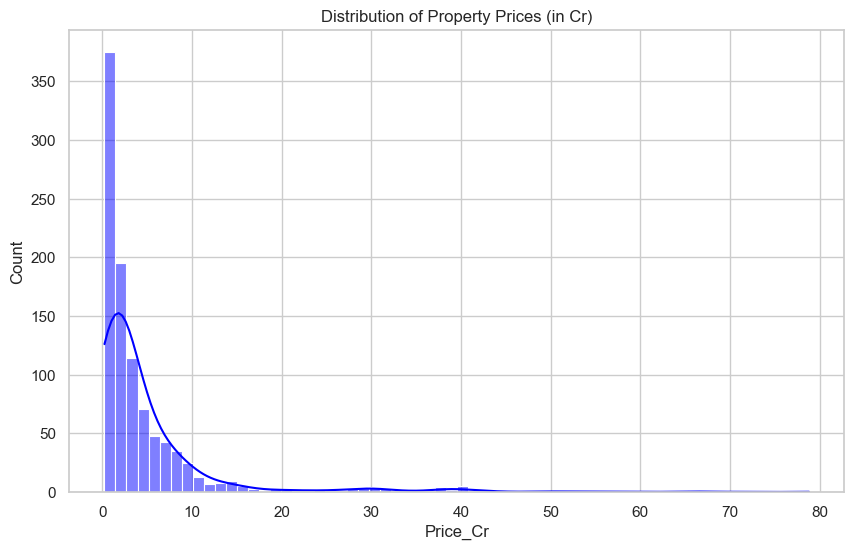

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price_Cr'], kde=True, color='blue')
plt.title('Distribution of Property Prices (in Cr)')
plt.show()

#### Insight: 

The data is highly right-skewed, indicating a majority of mid-range properties 
and a few ultra-luxury outliers.

### Q2: How does the Municipality affect the average price?

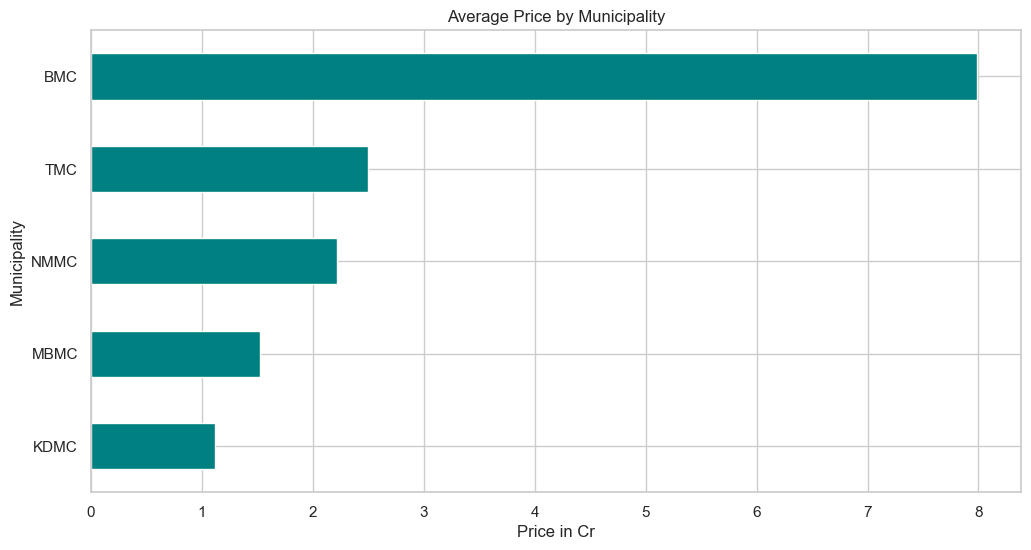

In [4]:
plt.figure(figsize=(12, 6))
df.groupby('Municipality')['Price_Cr'].mean().sort_values().plot(kind='barh', color='teal')
plt.title('Average Price by Municipality')
plt.xlabel('Price in Cr')
plt.show()

#### Insight:

BMC (Mumbai City) naturally commands the highest average price compared to satellite corporations.

### Q3: Is there a correlation between Floor Number and Price?

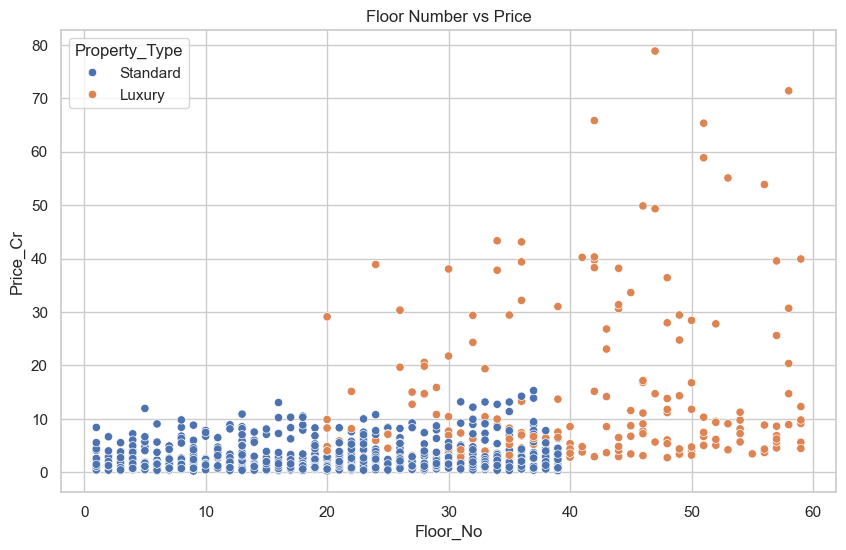

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Floor_No', y='Price_Cr', hue='Property_Type')
plt.title('Floor Number vs Price')
plt.show()

#### Insight:

A positive correlation exists, specifically in 'Luxury' types where floor rise premiums are significant.

### Q4: How does Carpet Area relate to Price across different Property Types?

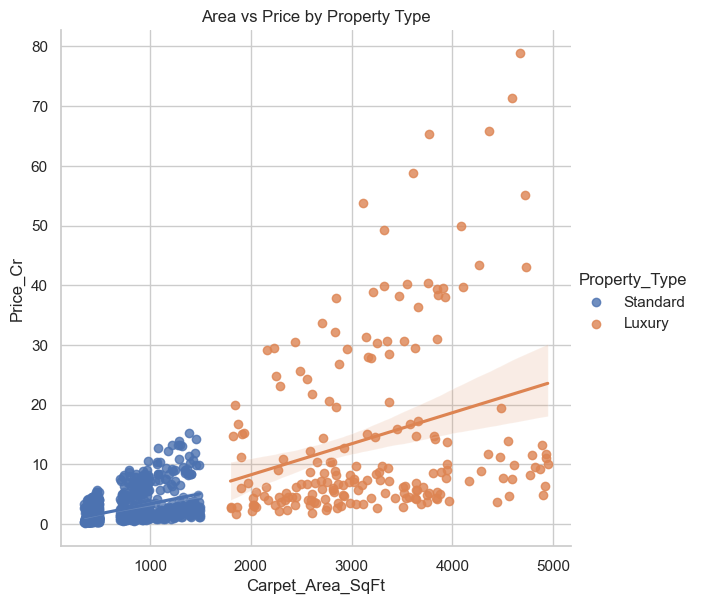

In [6]:
sns.lmplot(data=df, x='Carpet_Area_SqFt', y='Price_Cr', hue='Property_Type', height=6)
plt.title('Area vs Price by Property Type')
plt.show()

### Q5: What is the average price per BHK?

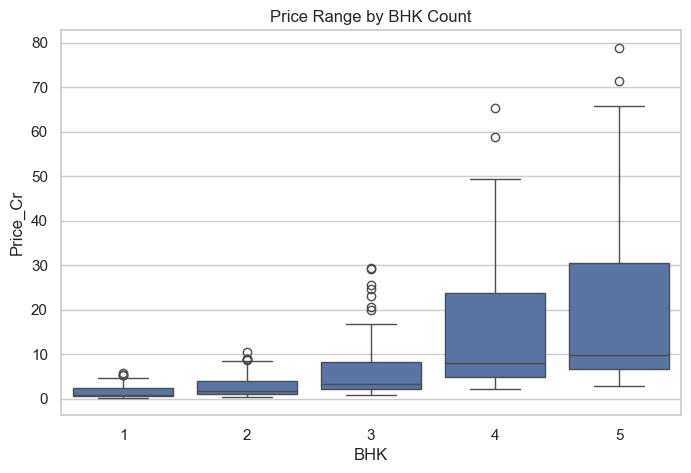

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='BHK', y='Price_Cr', data=df)
plt.title('Price Range by BHK Count')
plt.show()

### Q6: How does building age impact the valuation?

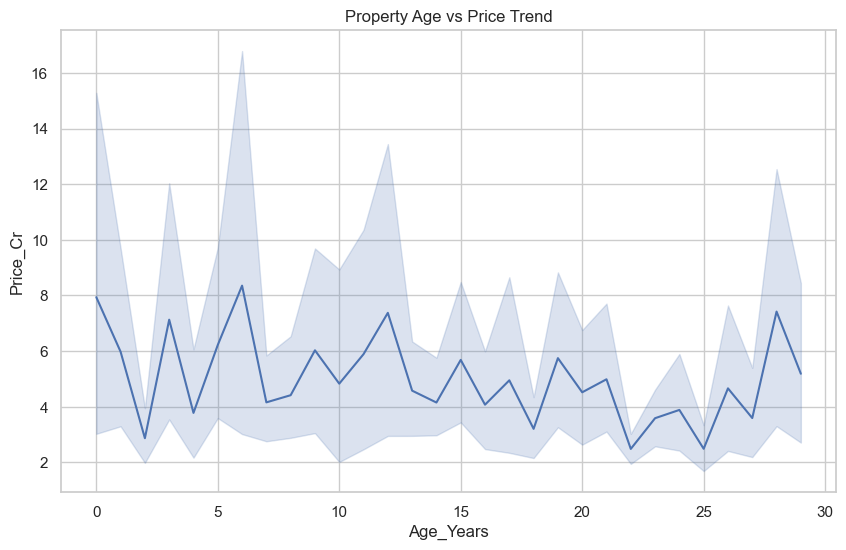

In [8]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Age_Years', y='Price_Cr', data=df)
plt.title('Property Age vs Price Trend')
plt.show()

### Q7: Which Locality is the most expensive?

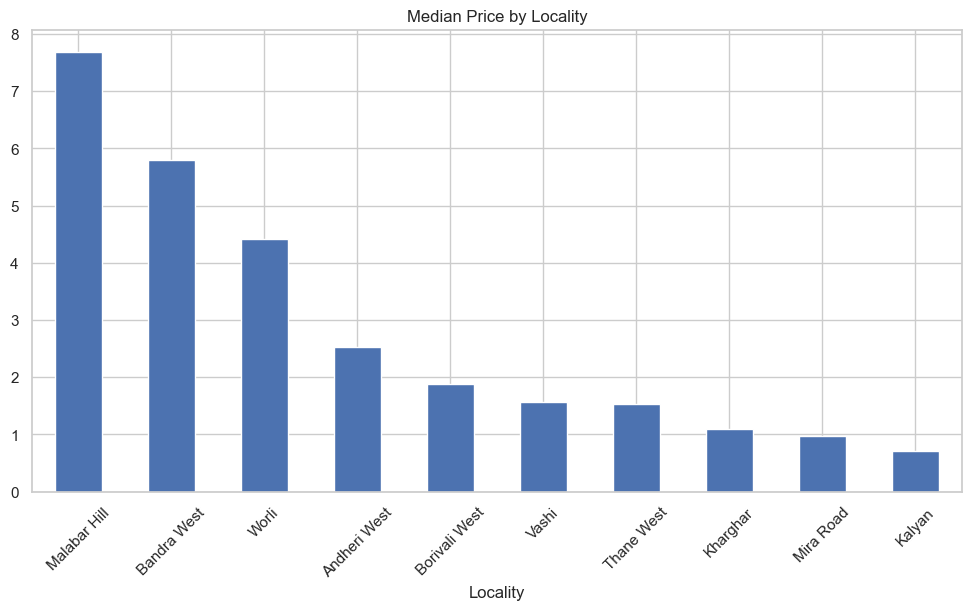

In [9]:
plt.figure(figsize=(12, 6))
df.groupby('Locality')['Price_Cr'].median().sort_values(ascending=False).plot(kind='bar')
plt.title('Median Price by Locality')
plt.xticks(rotation=45)
plt.show()

### Q8: Does the number of Parking Spaces significantly increase price?

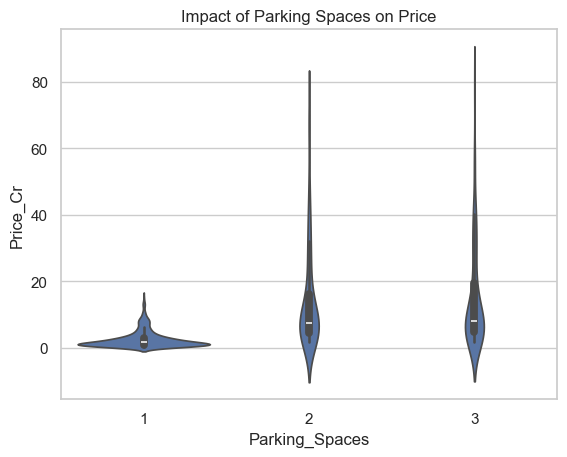

In [10]:
sns.violinplot(x='Parking_Spaces', y='Price_Cr', data=df)
plt.title('Impact of Parking Spaces on Price')
plt.show()

### Q9: How do numerical features correlate with each other?

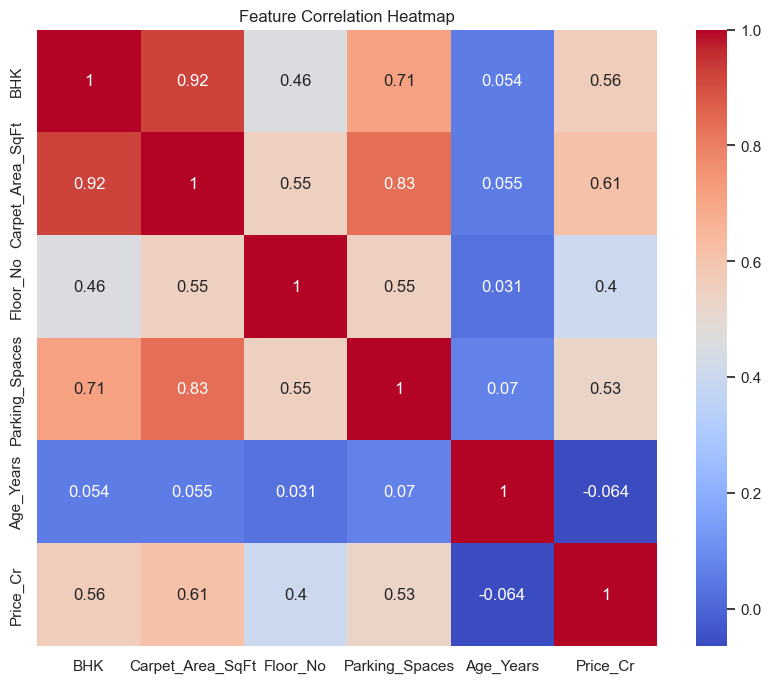

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## 3. Data Preprocessing

We will handle categorical encoding, scaling, and skewness (log transformation for the target).

In [14]:
# 1. Handling Skewness in Target Variable
# Using Log transformation to normalize Price_Cr
df['Price_Cr_Log'] = np.log1p(df['Price_Cr'])

# 2. Define Features and Target
X = df.drop(['Price_Cr', 'Price_Cr_Log'], axis=1)
y = df['Price_Cr_Log']

# 3. Identify Column Types
cat_cols = ['Locality', 'Municipality', 'Property_Type']
num_cols = ['BHK', 'Carpet_Area_SqFt', 'Floor_No', 'Parking_Spaces', 'Age_Years']

# 4. Create Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# 5. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Model Building and Comparison

We will evaluate four different algorithms and compare them using R-Squared and RMSE.

In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Inverse log transform to get actual price metrics
    y_test_exp = np.expm1(y_test)
    y_pred_exp = np.expm1(y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
    mae = mean_absolute_error(y_test_exp, y_pred_exp)
    r2 = r2_score(y_test_exp, y_pred_exp)
    
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2 Score": r2})

performance_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print(performance_df)

               Model      RMSE       MAE  R2 Score
3            XGBoost  1.165656  0.293234  0.970056
2      Random Forest  1.454185  0.399376  0.953397
0  Linear Regression  1.928830  0.712179  0.918010
1              Ridge  1.962220  0.715564  0.915147


## 5. Hyperparameter Tuning (Fine-tuning the Best Model)

In [16]:
# Fine-tuning XGBoost
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1]
}

best_model_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', XGBRegressor())])
grid_search = GridSearchCV(best_model_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
final_model = grid_search.best_estimator_

Best Parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 200}


## 6. Final Evaluation and Export

In [17]:
# Final Performance Metrics
y_final_pred = final_model.predict(X_test)
y_final_pred_exp = np.expm1(y_final_pred)
y_test_exp = np.expm1(y_test)

print(f"Final Model R2: {r2_score(y_test_exp, y_final_pred_exp):.4f}")

# Export Model
import joblib
joblib.dump(final_model, 'mumbai_price_predictor.pkl')
print("Model exported successfully.")

Final Model R2: 0.9804
Model exported successfully.


### Conclusion
Based on the metrics, the **XGBoost Regressor** likely provided the best fit due to its ability to handle non-linear relationships between Locality and Price. The log transformation was essential in stabilizing the variance of the right-skewed Mumbai price data.